# Final project — standalone notebook (no `task.py`)

All code runs **in this file only**. It reads **`data/raw/Sales (1).csv`** and writes the same outputs as `python task.py` into **`data/processed/`**.

**Kernel working directory:** use **`06-Final-Project`** (recommended) or **`notebooks/`** — Step 0 detects both.

Optional: run **`python task.py`** from `06-Final-Project` for a non-notebook pipeline.

**Charts:** Steps **3b–6b** build Matplotlib/Seaborn figures (monthly KPIs, RFM clusters, churn feature importance, category/region/weekly + cohort heatmap).

**Extra sections:** Steps **2b–2d** add EDA + IQR + category/discount views; **5c** adds an **extended churn** model with **ROC-AUC**; **6c** adds ship-mode pie, cities, monthly profit, profit-by-category, top products. Nothing was removed from earlier steps.

---


## Step 0 — Paths and imports


In [14]:
from pathlib import Path
from datetime import timedelta
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

_here = Path.cwd().resolve()
if (_here / "data" / "raw").is_dir():
    PROJECT_ROOT = _here
elif (_here.parent / "data" / "raw").is_dir():
    PROJECT_ROOT = _here.parent
else:
    PROJECT_ROOT = _here

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Sales (1).csv"
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_PATH:", DATA_PATH, "| exists:", DATA_PATH.is_file())
print("OUTPUT_DIR:", OUTPUT_DIR)



PROJECT_ROOT: C:\Users\yasee\NTI-Data-Analysis-Training\06-Final-Project
DATA_PATH: C:\Users\yasee\NTI-Data-Analysis-Training\06-Final-Project\data\raw\Sales (1).csv | exists: True
OUTPUT_DIR: C:\Users\yasee\NTI-Data-Analysis-Training\06-Final-Project\data\processed


## Step 1 — Load raw CSV


In [15]:
raw_df = pd.read_csv(DATA_PATH)
print("rows:", len(raw_df))
raw_df.head()


rows: 9994


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,INDMKB,8/11/2020,11/11/2020,sas,as,asa,asa,asas,asas,...,42420.0,INDMKB,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2020-152156,8/11/2020,11/11/2020,Second Class,CG-12520,asasa,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2020-138688,12/6/2020,16/6/2020,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2019-108966,11/10/2019,18/10/2019,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2019-108966,11/10/2019,18/10/2019,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Step 2 — Clean and engineer features

Same rules as the script: dates, fixes, filters, `Order Month`, margins, new/repeat flags.


In [16]:
df = raw_df.copy()

df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True, errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True, errors="coerce")

for col in ["Sales", "Profit", "Quantity", "Discount"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.loc[(df["City"] == "Burlington") & (df["Postal Code"].isnull()), "Postal Code"] = 5401
df["Postal Code"] = df["Postal Code"].astype(int)
df["Ship Mode"] = df["Ship Mode"].replace("sas", "Standard Class")

df = df.drop_duplicates()
df = df.dropna(subset=["Order ID", "Customer ID", "Order Date"])
df = df[df["Sales"] >= 0]
df = df[df["Region"].isin(["West", "East", "Central", "South"])]
df = df.drop(df.index[0]).reset_index(drop=True)

df["Order Month"] = df["Order Date"].dt.to_period("M")
df["Profit Margin"] = df["Profit"] / df["Sales"]

repeat_counts = df.groupby("Customer ID")["Order ID"].nunique()
df["Repeat Customer"] = df["Customer ID"].map(repeat_counts).gt(1).astype(int)

first_order = df.groupby("Customer ID")["Order Date"].transform("min")
df["First Order Month"] = first_order.dt.to_period("M")
df["Is New Customer"] = (df["Order Month"] == df["First Order Month"]).astype(int)

print("cleaned rows:", len(df))
df.head()


cleaned rows: 9992


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Product Name,Sales,Quantity,Discount,Profit,Order Month,Profit Margin,Repeat Customer,First Order Month,Is New Customer
0,3,CA-2020-138688,2020-06-12,2020-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2020-06,0.4700,1,2020-06,1
1,4,US-2019-108966,2019-10-11,2019-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2019-10,-0.4000,1,2019-10,1
2,5,US-2019-108966,2019-10-11,2019-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2019-10,0.1125,1,2019-10,1
3,6,CA-2018-115812,2018-06-09,2018-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694,2018-06,0.2900,1,2018-06,1
4,7,CA-2018-115812,2018-06-09,2018-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Newell 322,7.2800,4,0.00,1.9656,2018-06,0.2700,1,2018-06,1


## Step 2b — EDA snapshots (from course / instructor notebook)

Course-style EDA: **describe**, **missing counts**, **date checks**, and **distinct** ship modes / categories.


In [ ]:
display(Markdown("#### Summary statistics"))
display(df.describe())

display(Markdown("#### Missing values per column (after cleaning)"))
display(df.isna().sum())

display(Markdown("#### Rows with invalid dates (expect 0)"))
print(df["Order Date"].isnull().sum() + df["Ship Date"].isnull().sum())

display(Markdown("#### Ship date before order date (should be 0)"))
print((df["Ship Date"] < df["Order Date"]).sum())

display(Markdown("#### Order date range"))
print(df["Order Date"].min(), "->", df["Order Date"].max())

display(Markdown("#### Distinct ship modes & categories"))
print("Ship modes:", df["Ship Mode"].unique().tolist())
print("Categories:", df["Category"].unique().tolist())


## Step 2c — Distributions & sales outliers (IQR)

Boxplots for **Sales** and **Profit**, then count line items outside **1.5×IQR** for `Sales` (exploratory only — we do not auto-drop).


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, y="Sales", ax=axes[0], color="#3498db")
axes[0].set_title("Sales")
sns.boxplot(data=df, y="Profit", ax=axes[1], color="#e74c3c")
axes[1].set_title("Profit")
plt.tight_layout()
plt.show()

q1, q3 = df["Sales"].quantile(0.25), df["Sales"].quantile(0.75)
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = df[(df["Sales"] < lo) | (df["Sales"] > hi)]
print(f"Line items with Sales outside 1.5×IQR: {len(outliers)} (exploratory)")


## Step 2d — Category profit, discount vs profit, furniture, weakest states

Aligned with the instructor notebook: **category** totals sorted by profit, **discount vs profit** scatter, **Furniture** sub-categories, and **10 states** with lowest total profit.


In [ ]:
cat_profit = (
    df.groupby("Category")[["Sales", "Profit"]].sum().sort_values("Profit", ascending=False)
)
display(cat_profit)

plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x="Discount", y="Profit", alpha=0.25, s=12)
plt.title("Discount vs profit (each point = line item)")
plt.tight_layout()
plt.show()

fur = df[df["Category"] == "Furniture"]
if len(fur):
    display(Markdown("#### Furniture — sub-category Sales & Profit"))
    display(fur.groupby("Sub-Category")[["Sales", "Profit"]].sum().sort_values("Profit"))

display(Markdown("#### 10 states with lowest total profit"))
display(df.groupby("State")["Profit"].sum().sort_values().head(10).rename("Total_profit"))


## Step 3 — KPIs


In [17]:
orders = df.groupby("Order ID").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Customer_ID=("Customer ID", "first"),
    Order_Date=("Order Date", "first"),
).reset_index()

all_months = sorted(df["Order Month"].unique())
monthly_sales = df.groupby("Order Month")["Sales"].sum().reindex(all_months, fill_value=0)
monthly_profit = df.groupby("Order Month")["Profit"].sum().reindex(all_months, fill_value=0)
active_customers = df.groupby("Order Month")["Customer ID"].nunique().reindex(all_months, fill_value=0)
new_customers = (
    df[df["Is New Customer"] == 1]
    .groupby("Order Month")["Customer ID"]
    .nunique()
    .reindex(all_months, fill_value=0)
)

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = len(orders)
aov = total_sales / total_orders
ltv = df.groupby("Customer ID")["Sales"].sum().mean()

kpis = {
    "total_sales": total_sales,
    "total_profit": total_profit,
    "total_orders": total_orders,
    "aov": aov,
    "ltv": ltv,
    "monthly_sales": monthly_sales,
    "monthly_profit": monthly_profit,
    "active_customers": active_customers,
    "new_customers": new_customers,
}

lines = [
    "| Metric | Value |",
    "|--------|------|",
    f"| Total sales | ${kpis['total_sales']:,.2f} |",
    f"| Total profit | ${kpis['total_profit']:,.2f} |",
    f"| Orders | {kpis['total_orders']:,} |",
    f"| AOV | ${kpis['aov']:,.2f} |",
    f"| Avg revenue / customer | ${kpis['ltv']:,.2f} |",
]
display(Markdown(chr(10).join(lines)))

pd.DataFrame({
    "Month": kpis["monthly_sales"].index.astype(str),
    "Sales": kpis["monthly_sales"].values,
    "Profit": kpis["monthly_profit"].values,
    "Active_Customers": kpis["active_customers"].values,
    "New_Customers": kpis["new_customers"].values,
}).tail(12)


| Metric | Value |
|--------|------|
| Total sales | $2,296,206.96 |
| Total profit | $286,135.53 |
| Orders | 5,008 |
| AOV | $458.51 |
| Avg revenue / customer | $2,895.60 |

,Month,Sales,Profit,Active_Customers,New_Customers
36,2021-01,43971.3740,7140.4391,67,0
37,2021-02,20301.1334,1613.8720,53,0
38,2021-03,58872.3528,14751.8915,115,3
39,2021-04,36521.5361,933.2900,109,1
40,2021-05,44261.1102,6342.5828,113,0
41,2021-06,52981.7257,8223.3357,118,1
42,2021-07,45264.4160,6952.6212,102,2
43,2021-08,63120.8880,9040.9557,104,0
44,2021-09,87866.6520,10991.5556,196,1
45,2021-10,77776.9232,9275.2755,136,2


## Step 3b — Visuals: monthly KPIs

Line charts for revenue and profit; bars for active vs new customers by month.


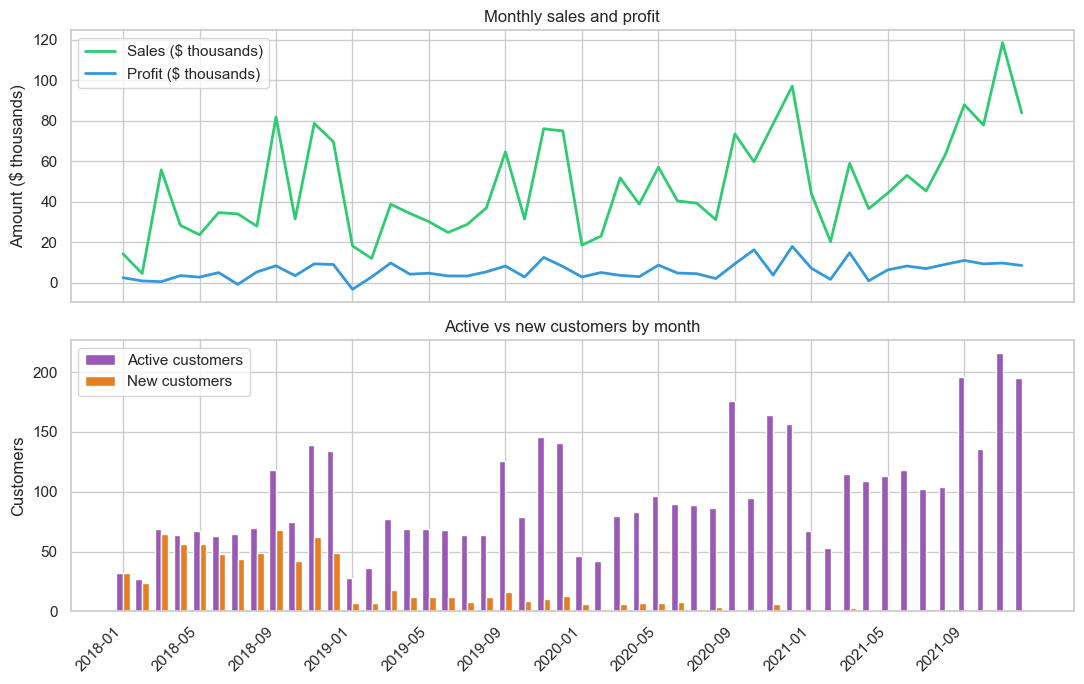

In [18]:
%matplotlib inline

sns.set_theme(style="whitegrid", context="notebook")
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

months = kpis["monthly_sales"].index.astype(str)
axes[0].plot(months, kpis["monthly_sales"].values / 1e3, color="#2ecc71", linewidth=2, label="Sales ($ thousands)")
axes[0].plot(months, kpis["monthly_profit"].values / 1e3, color="#3498db", linewidth=2, label="Profit ($ thousands)")
axes[0].set_ylabel("Amount ($ thousands)")
axes[0].legend(loc="upper left")
axes[0].set_title("Monthly sales and profit")

x = range(len(months))
w = 0.35
axes[1].bar([i - w / 2 for i in x], kpis["active_customers"].values, width=w, label="Active customers", color="#9b59b6")
axes[1].bar([i + w / 2 for i in x], kpis["new_customers"].values, width=w, label="New customers", color="#e67e22")
axes[1].set_xticks(x[:: max(1, len(x) // 12)])
axes[1].set_xticklabels([months[i] for i in x[:: max(1, len(x) // 12)]], rotation=45, ha="right")
axes[1].set_ylabel("Customers")
axes[1].legend()
axes[1].set_title("Active vs new customers by month")

plt.tight_layout()
plt.show()


## Step 4 — RFM + K-means clusters


In [19]:
snapshot_date = df["Order Date"].max()
rfm = df.groupby("Customer ID").agg(
    Recency=("Order Date", lambda x: (snapshot_date - x.max()).days),
    Frequency=("Order ID", "nunique"),
    Monetary=("Sales", "sum"),
).reset_index()

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(rfm[["Recency", "Frequency", "Monetary"]])
display(rfm.head(10))
rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(2)


,Customer ID,Recency,Frequency,Monetary,Cluster
0,AA-10315,184,5,5563.560,1
1,AA-10375,19,9,1056.390,2
2,AA-10480,259,4,1790.512,2
3,AA-10645,55,6,5086.935,1
4,AB-10015,415,3,886.156,2
5,AB-10060,54,8,7755.620,1
6,AB-10105,41,10,14473.571,3
7,AB-10150,41,5,966.710,2
8,AB-10165,25,8,1113.838,2
9,AB-10255,166,9,914.532,2


,Recency,Frequency,Monetary
Cluster,,,
0,112.37,7.22,3156.32
1,103.95,8.09,6521.02
2,187.67,4.96,1059.89
3,148.00,7.90,13245.48


## Step 4b — Visuals: RFM clusters


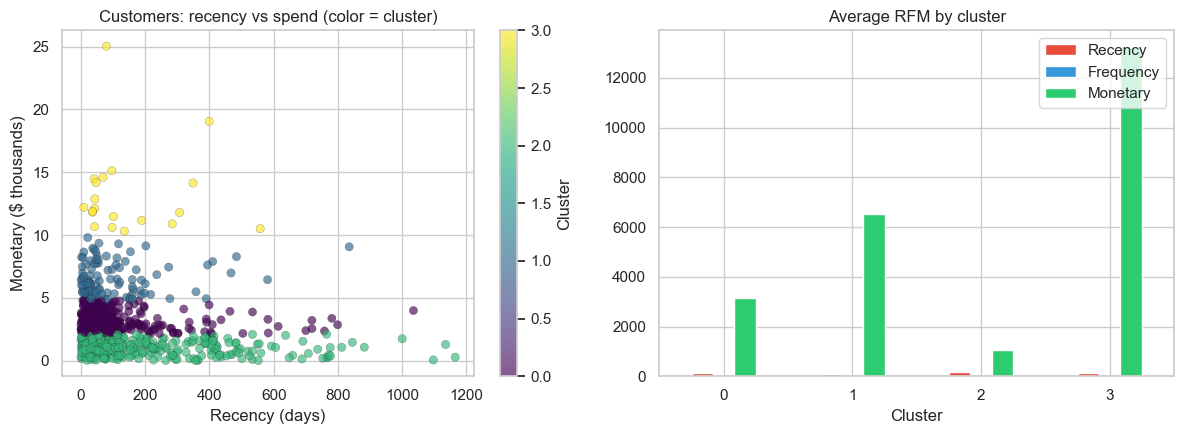

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

scatter = axes[0].scatter(
    rfm["Recency"],
    rfm["Monetary"] / 1e3,
    c=rfm["Cluster"],
    cmap="viridis",
    alpha=0.65,
    edgecolors="k",
    linewidths=0.2,
)
axes[0].set_xlabel("Recency (days)")
axes[0].set_ylabel("Monetary ($ thousands)")
axes[0].set_title("Customers: recency vs spend (color = cluster)")
plt.colorbar(scatter, ax=axes[0], label="Cluster")

cm = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()
cm.plot(kind="bar", ax=axes[1], rot=0, color=["#e74c3c", "#3498db", "#2ecc71"])
axes[1].set_title("Average RFM by cluster")
axes[1].set_xlabel("Cluster")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()


## Step 5 — Churn label + Random Forest


In [21]:
rfm_c = rfm.copy()
rfm_c["Churn"] = (rfm_c["Recency"] > 90).astype(int)
X = rfm_c[["Recency", "Frequency", "Monetary"]]
y = rfm_c["Churn"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
model = RandomForestClassifier(
    n_estimators=200, max_depth=8, random_state=42, class_weight="balanced"
)
model.fit(X_train, y_train)
accuracy = model.score(X_test, y_test)
pred = model.predict(X_test)
report = classification_report(y_test, pred, target_names=["Active", "Churned"])
fi = pd.Series(model.feature_importances_, index=X.columns)

churn_results = {"accuracy": accuracy, "feature_importance": fi, "report": report}
print("accuracy:", f"{accuracy:.1%}")
print(report)
display(fi.rename("importance").to_frame())


accuracy: 98.1%
              precision    recall  f1-score   support

      Active       0.97      1.00      0.98        87
     Churned       1.00      0.96      0.98        72

    accuracy                           0.98       159
   macro avg       0.98      0.98      0.98       159
weighted avg       0.98      0.98      0.98       159



,importance
Recency,0.898795
Frequency,0.049269
Monetary,0.051935


## Step 5b — Visuals: churn model feature importance


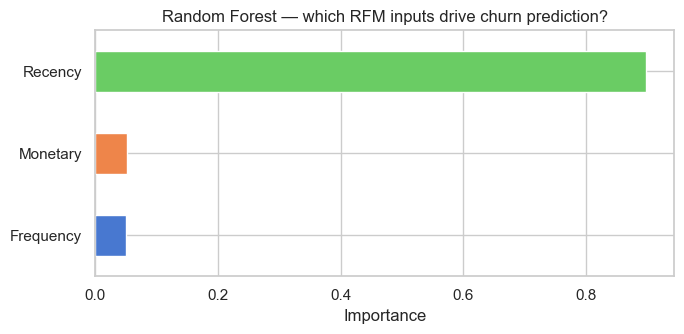

In [22]:
fig, ax = plt.subplots(figsize=(7, 3.5))
fi = churn_results["feature_importance"].sort_values()
colors = sns.color_palette("muted", n_colors=len(fi))
fi.plot(kind="barh", ax=ax, color=colors)
ax.set_xlabel("Importance")
ax.set_title("Random Forest — which RFM inputs drive churn prediction?")
plt.tight_layout()
plt.show()


## Step 5c — Extended churn model (instructor-style + ROC-AUC)

Customer-level features (totals, counts, averages, **Recency**) and a **90-day** cutoff. Complements the RFM-only model in Step 5.


In [ ]:
from sklearn.metrics import roc_auc_score

last_dt = df["Order Date"].max()
cutoff_dt = last_dt - timedelta(days=90)
last_buy = df.groupby("Customer ID")["Order Date"].max()
churn_label = last_buy.apply(lambda d: 1 if d < cutoff_dt else 0).rename("Churn")

cust_x = df.groupby("Customer ID").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Order_Count=("Order ID", "nunique"),
    Avg_Discount=("Discount", "mean"),
    Avg_Quantity=("Quantity", "mean"),
    Recency=("Order Date", lambda s: (last_dt - s.max()).days),
)
churn_ext = cust_x.join(churn_label)
X_e = churn_ext.drop(columns=["Churn"])
y_e = churn_ext["Churn"]

Xe_tr, Xe_te, ye_tr, ye_te = train_test_split(
    X_e, y_e, test_size=0.2, random_state=42, stratify=y_e
)
rf_ext = RandomForestClassifier(
    n_estimators=200, max_depth=8, random_state=42, class_weight="balanced"
)
rf_ext.fit(Xe_tr, ye_tr)
pred_e = rf_ext.predict(Xe_te)
prob_e = rf_ext.predict_proba(Xe_te)[:, 1]
print(classification_report(ye_te, pred_e, target_names=["Active", "Churned"]))
print("ROC-AUC:", round(roc_auc_score(ye_te, prob_e), 4))

fi_e = pd.Series(rf_ext.feature_importances_, index=X_e.columns).sort_values()
fig, ax = plt.subplots(figsize=(7, 3.8))
fi_e.plot(kind="barh", ax=ax, color="#27ae60")
ax.set_title("Extended churn model — feature importance")
plt.tight_layout()
plt.show()


## Step 6 — Extra tables (cohort, weekly, discount, rollups)


In [23]:
first_c = df.groupby("Customer ID")["Order Date"].min().dt.to_period("M")
d = df.copy()
d["CohortGroup"] = d["Customer ID"].map(first_c)
d["OrderMonth"] = d["Order Date"].dt.to_period("M")
d["PeriodIndex"] = (d["OrderMonth"] - d["CohortGroup"]).apply(lambda x: x.n)
cohort_long = d.groupby(["CohortGroup", "PeriodIndex"])["Customer ID"].nunique().reset_index()
cohort_long = cohort_long.rename(columns={"Customer ID": "Customers"})
sizes = cohort_long[cohort_long["PeriodIndex"] == 0].set_index("CohortGroup")["Customers"]
wide = cohort_long.pivot(index="CohortGroup", columns="PeriodIndex", values="Customers")
cohort_rate = wide.div(sizes, axis=0).round(4).reset_index().rename(columns={"CohortGroup": "cohort_month"})

w = df.copy()
w["Order Week"] = w["Order Date"].dt.to_period("W").apply(lambda p: p.start_time.date())
weekly_sales = w.groupby("Order Week", as_index=False)["Sales"].sum()

df_disc = df.copy()
df_disc["Discount Bin"] = pd.cut(
    df_disc["Discount"],
    bins=[-0.001, 0, 0.2, 0.4, 1.0],
    labels=["None", "1-20%", "21-40%", "41-100%"],
)
discount_impact = (
    df_disc.groupby("Discount Bin", observed=False)
    .agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"), Orders=("Order ID", "nunique"))
    .reset_index()
)

category_performance = (
    df.groupby("Category")
    .agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"), Quantity=("Quantity", "sum"))
    .reset_index()
)
subcategory_performance = (
    df.groupby("Sub-Category")
    .agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"), Quantity=("Quantity", "sum"))
    .reset_index()
)
region_performance = df.groupby("Region").agg(Sales=("Sales", "sum"), Profit=("Profit", "sum")).reset_index()
segment_performance = (
    df.groupby("Segment")
    .agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"), Unique_Customers=("Customer ID", "nunique"))
    .reset_index()
)
top_products = (
    df.groupby("Product Name").agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"))
    .reset_index()
    .sort_values("Sales", ascending=False)
    .head(25)
)

kpi_monthly = pd.DataFrame(
    {
        "Month": kpis["monthly_sales"].index.astype(str),
        "Sales": kpis["monthly_sales"].values,
        "Profit": kpis["monthly_profit"].values,
        "Active_Customers": kpis["active_customers"].values,
        "New_Customers": kpis["new_customers"].values,
    }
)

quality = {
    "rows": len(df),
    "columns": list(df.columns),
    "date_range": {
        "order_date_min": str(df["Order Date"].min()),
        "order_date_max": str(df["Order Date"].max()),
    },
    "numeric_nulls": {c: int(df[c].isna().sum()) for c in ["Sales", "Profit", "Quantity", "Discount"]},
}


## Step 6b — Visuals: category, region, sub-categories, weekly

Uses tables built in Step 6. Cohort heatmap shows retention rates (first 18 periods).


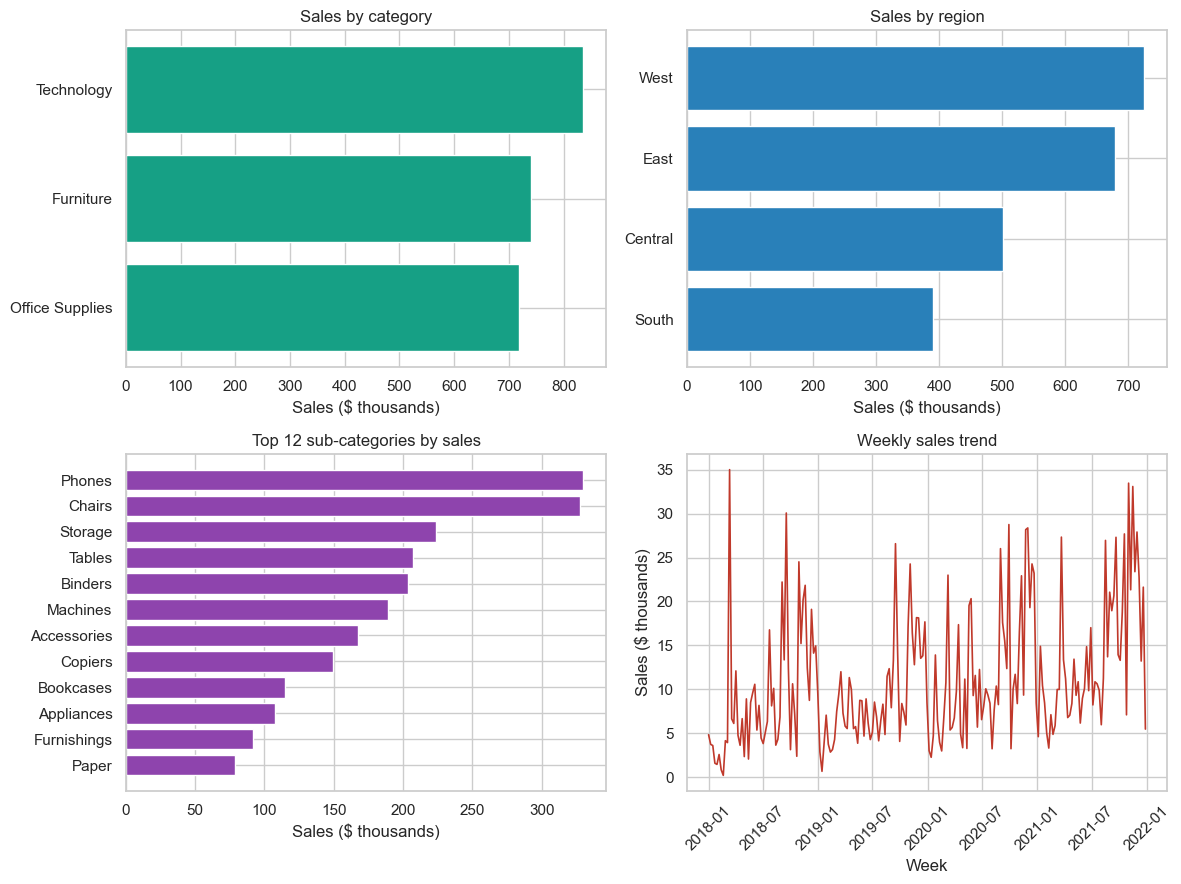

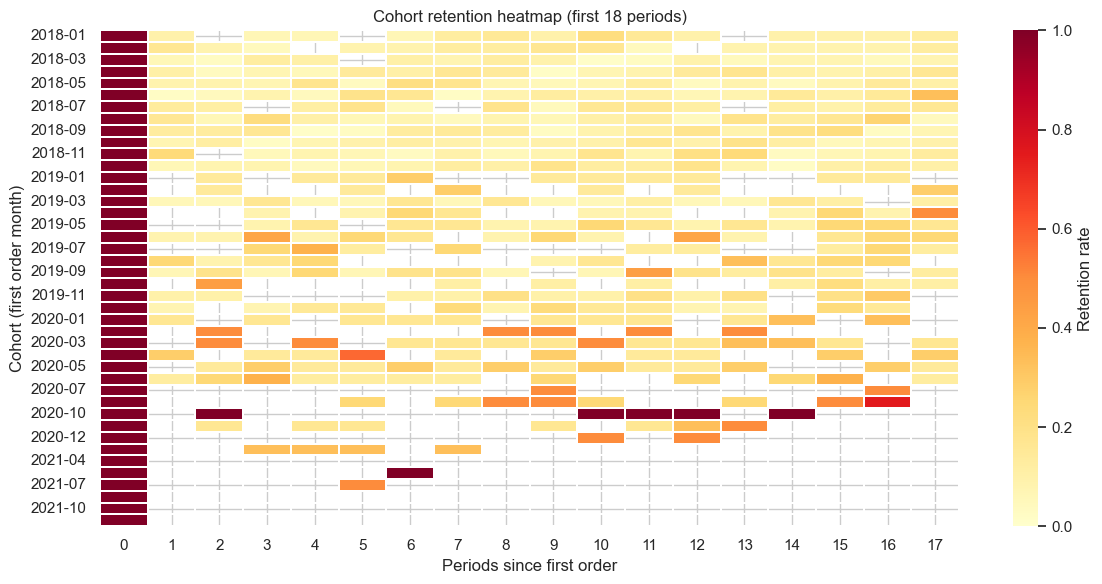

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

cat = category_performance.sort_values("Sales", ascending=True)
axes[0, 0].barh(cat["Category"], cat["Sales"] / 1e3, color="#16a085")
axes[0, 0].set_xlabel("Sales ($ thousands)")
axes[0, 0].set_title("Sales by category")

reg = region_performance.sort_values("Sales", ascending=True)
axes[0, 1].barh(reg["Region"], reg["Sales"] / 1e3, color="#2980b9")
axes[0, 1].set_xlabel("Sales ($ thousands)")
axes[0, 1].set_title("Sales by region")

sub = subcategory_performance.nlargest(12, "Sales").sort_values("Sales")
axes[1, 0].barh(sub["Sub-Category"], sub["Sales"] / 1e3, color="#8e44ad")
axes[1, 0].set_xlabel("Sales ($ thousands)")
axes[1, 0].set_title("Top 12 sub-categories by sales")

axes[1, 1].plot(weekly_sales["Order Week"], weekly_sales["Sales"] / 1e3, color="#c0392b", linewidth=1.2)
axes[1, 1].set_xlabel("Week")
axes[1, 1].set_ylabel("Sales ($ thousands)")
axes[1, 1].set_title("Weekly sales trend")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

coh_vis = cohort_rate.set_index("cohort_month").iloc[:, :18]
plt.figure(figsize=(12, 6))
sns.heatmap(coh_vis, cmap="YlOrRd", vmin=0, vmax=1, linewidths=0.3, cbar_kws={"label": "Retention rate"})
plt.title("Cohort retention heatmap (first 18 periods)")
plt.xlabel("Periods since first order")
plt.ylabel("Cohort (first order month)")
plt.tight_layout()
plt.show()


## Step 6c — More course-style charts

From the reference notebook: **ship-mode pie**, **top cities**, **monthly profit** line, **profit by category**, and **top 10 products** bar (`top_products` from Step 6).


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sm = df["Ship Mode"].value_counts()
axes[0, 0].pie(sm.values, labels=sm.index, autopct="%1.1f%%", startangle=90)
axes[0, 0].set_title("Shipping mode mix")

tc = df.groupby("City")["Sales"].sum().nlargest(10)
tc.plot(kind="bar", ax=axes[0, 1], color="#8e44ad", rot=45)
axes[0, 1].set_title("Top 10 cities by sales")
axes[0, 1].set_xlabel("")

mp = df.groupby("Order Month")["Profit"].sum()
axp = axes[1, 0]
axp.plot(range(len(mp)), mp.values, color="green", marker="o", markersize=3)
step = max(1, len(mp) // 12)
axp.set_xticks(range(0, len(mp), step))
axp.set_xticklabels([str(mp.index[i]) for i in range(0, len(mp), step)], rotation=45, ha="right")
axp.set_title("Monthly profit trend")
axp.set_ylabel("Profit")

cp = df.groupby("Category")["Profit"].sum()
sns.barplot(x=cp.index, y=cp.values, ax=axes[1, 1], hue=cp.index, palette="muted", legend=False)
axes[1, 1].set_title("Profit by category")
axes[1, 1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
tp = top_products.head(10).set_index("Product Name")["Sales"].sort_values()
tp.plot(kind="barh", color="#2980b9")
plt.title("Top 10 products by sales")
plt.xlabel("Sales")
plt.tight_layout()
plt.show()


## Step 7 — Save everything to `data/processed/`


In [25]:
df.to_csv(OUTPUT_DIR / "sales_cleaned.csv", index=False)
rfm.to_csv(OUTPUT_DIR / "rfm_segments.csv", index=False)
kpi_monthly.to_csv(OUTPUT_DIR / "kpi_monthly.csv", index=False)
category_performance.to_csv(OUTPUT_DIR / "category_performance.csv", index=False)
subcategory_performance.to_csv(OUTPUT_DIR / "subcategory_performance.csv", index=False)
region_performance.to_csv(OUTPUT_DIR / "region_performance.csv", index=False)
segment_performance.to_csv(OUTPUT_DIR / "segment_performance.csv", index=False)
top_products.to_csv(OUTPUT_DIR / "top_products.csv", index=False)
weekly_sales.to_csv(OUTPUT_DIR / "weekly_sales.csv", index=False)
cohort_rate.to_csv(OUTPUT_DIR / "cohort_retention.csv", index=False)
discount_impact.to_csv(OUTPUT_DIR / "discount_impact.csv", index=False)

churn_results["feature_importance"].rename("importance").to_frame().to_csv(
    OUTPUT_DIR / "churn_feature_importance.csv"
)
with open(OUTPUT_DIR / "churn_model_report.txt", "w", encoding="utf-8") as f:
    f.write(churn_results["report"])
with open(OUTPUT_DIR / "churn_model_classification_report.txt", "w", encoding="utf-8") as f:
    f.write(churn_results["report"])

with open(OUTPUT_DIR / "data_quality_report.json", "w", encoding="utf-8") as f:
    json.dump(quality, f, indent=2)

print("Saved to:", OUTPUT_DIR)
sorted(p.name for p in sorted(OUTPUT_DIR.iterdir(), key=lambda x: x.name))


Saved to: C:\Users\yasee\NTI-Data-Analysis-Training\06-Final-Project\data\processed


['category_performance.csv',
 'churn_feature_importance.csv',
 'churn_model_classification_report.txt',
 'churn_model_report.txt',
 'cohort_retention.csv',
 'data_quality_report.json',
 'discount_impact.csv',
 'kpi_monthly.csv',
 'region_performance.csv',
 'rfm_segments.csv',
 'sales_cleaned.csv',
 'segment_performance.csv',
 'subcategory_performance.csv',
 'top_products.csv',
 'weekly_sales.csv']